In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_csv("../data/cleaned/cleaned_data.csv")
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                505206 non-null  float64
 1   Gender             505206 non-null  object 
 2   Tenure             505206 non-null  float64
 3   Usage Frequency    505206 non-null  float64
 4   Support Calls      505206 non-null  float64
 5   Payment Delay      505206 non-null  float64
 6   Subscription Type  505206 non-null  object 
 7   Contract Length    505206 non-null  object 
 8   Total Spend        505206 non-null  float64
 9   Last Interaction   505206 non-null  float64
 10  Churn              505206 non-null  float64
dtypes: float64(8), object(3)
memory usage: 42.4+ MB


## **Feature Importance & Engineering Strategy for Modeling**

**Expected Feature Importance (Based on EDA)**
Based on the bivariate analysis and correlation matrix, the features can be categorized by their anticipated predictive power:
* **High Importance:** `Support Calls` (highest positive correlation), `Payment Delay` (strong behavioral indicator), and `Contract Length` (massive churn rate in monthly contracts).
* **Moderate Importance:** `Age`, `Total Spend`, `Last Interaction`, and `Gender`. These features show distinct churn patterns but rely heavily on specific thresholds rather than general continuous trends.
* **Low/No Importance:** `Subscription Type`, `Usage Frequency`, and `Tenure`. These features exhibited nearly identical distributions across both churned and retained customers.

**Feature Engineering for Linear Models**
While tree-based models (like Random Forest or XGBoost) can natively capture the sharp cut-offs and non-linear relationships observed in the EDA, linear models (such as Logistic Regression) cannot. Linear models assume a constant rate of change, which contradicts the step-wise behavior seen in our data. To maximize the performance of linear models, we will engineer the following explicit binary and interaction features to capture these thresholds:

* **`Critical_Support_Calls` (Binary):** 1 if `Support Calls` > 3, else 0. (Captures the 100% churn rate observed after 4 calls).
* **`Severe_Payment_Delay` (Binary):** 1 if `Payment Delay` > 20, else 0. (Captures the sudden spike in churn for late payers).
* **`High_Risk_Age` (Binary):** 1 if `Age` > 50, else 0. (Highlights the specific demographic drop-off).
* **`Low_Spend_Flag` (Binary):** 1 if `Total Spend` < 500, else 0. (Separates the high-churn, low-spend tier from the stable, high-spend tier).
* **`Avg_Monthly_Spend` (Continuous Interaction):** `Total Spend` / `Tenure`. (Provides a normalized spending metric to better evaluate customer value over time).

In [5]:
data_copy = data.copy()

data_copy['Critical_Support_Calls'] = (data['Support Calls'] > 3).astype(int)
data_copy['Server_Payment_Delay'] = (data['Payment Delay'] > 20).astype(int)
data_copy['High_Risk_Age'] = (data['Age'] > 50).astype(int)
data_copy['Low_Spend_Flag'] = (data['Total Spend'] < 500).astype(int)
data_copy.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Critical_Support_Calls,Server_Payment_Delay,High_Risk_Age,Low_Spend_Flag
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,1,0,0,0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,1,0,1,0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,1,0,1,1
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,1,0,1,1
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,1,0,0,0


## Split & Preprocessing Original Features

In [5]:
# Split
from sklearn.model_selection import train_test_split
X = data.drop(columns= 'Churn')
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.1, random_state= 42, stratify= y)

In [6]:
# Encode
from sklearn.preprocessing import OneHotEncoder

cols = ['Gender', 'Subscription Type', 'Contract Length']
encoder = OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)

train_encoded = encoder.fit_transform(X_train[cols])
test_encoded = encoder.transform(X_test[cols])

cols_names = encoder.get_feature_names_out(cols)

train_encoded = pd.DataFrame(train_encoded, columns= cols_names, index= X_train.index)
test_encoded = pd.DataFrame(test_encoded, columns= cols_names, index= X_test.index)

X_train = X_train.drop(columns= cols)
X_test = X_test.drop(columns= cols)

X_train = pd.concat([X_train, train_encoded], axis= 1)
X_test = pd.concat([X_test, test_encoded], axis= 1)

In [7]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_scale = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction' ]

X_train[cols_scale] = scaler.fit_transform(X_train[cols_scale])
X_test[cols_scale] = scaler.transform(X_test[cols_scale])

In [8]:
display((X_train[X_train.select_dtypes('number').columns] % 1 == 0).all())
display((X_test[X_test.select_dtypes('number').columns] % 1 == 0).all())

Age                           False
Tenure                        False
Usage Frequency               False
Support Calls                 False
Payment Delay                 False
Total Spend                   False
Last Interaction              False
Gender_Female                  True
Gender_Male                    True
Subscription Type_Basic        True
Subscription Type_Premium      True
Subscription Type_Standard     True
Contract Length_Annual         True
Contract Length_Monthly        True
Contract Length_Quarterly      True
dtype: bool

Age                           False
Tenure                        False
Usage Frequency               False
Support Calls                 False
Payment Delay                 False
Total Spend                   False
Last Interaction              False
Gender_Female                  True
Gender_Male                    True
Subscription Type_Basic        True
Subscription Type_Premium      True
Subscription Type_Standard     True
Contract Length_Annual         True
Contract Length_Monthly        True
Contract Length_Quarterly      True
dtype: bool

In [9]:
int_cols = ['Gender_Female', 'Gender_Male',
       'Subscription Type_Basic', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Contract Length_Annual',
       'Contract Length_Monthly', 'Contract Length_Quarterly']

X_train[int_cols] = X_train[int_cols].astype('int8')
X_test[int_cols] = X_test[int_cols].astype('int8')

## Split & Preprocessing new Features

In [11]:
# Split
from sklearn.model_selection import train_test_split

X_new = data_copy.drop(columns= 'Churn')
y_new = data_copy['Churn']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size= 0.1, random_state= 42, stratify= y)

In [12]:
# Encode
from sklearn.preprocessing import OneHotEncoder

cols = ['Gender', 'Subscription Type', 'Contract Length']
encoder = OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)

train_encoded = encoder.fit_transform(X_train_new[cols])
test_encoded = encoder.transform(X_test_new[cols])

cols_names = encoder.get_feature_names_out(cols)

train_encoded = pd.DataFrame(train_encoded, columns= cols_names, index= X_train_new.index)
test_encoded = pd.DataFrame(test_encoded, columns= cols_names, index= X_test_new.index)

X_train_new = X_train_new.drop(columns= cols)
X_test_new = X_test_new.drop(columns= cols)

X_train_new = pd.concat([X_train_new, train_encoded], axis= 1)
X_test_new = pd.concat([X_test_new, test_encoded], axis= 1)

In [13]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_scale = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction' ]

X_train_new[cols_scale] = scaler.fit_transform(X_train_new[cols_scale])
X_test_new[cols_scale] = scaler.transform(X_test_new[cols_scale])

In [14]:
display((X_train_new[X_train_new.select_dtypes('number').columns] % 1 == 0).all())
display((X_test_new[X_test_new.select_dtypes('number').columns] % 1 == 0).all())

Age                           False
Tenure                        False
Usage Frequency               False
Support Calls                 False
Payment Delay                 False
Total Spend                   False
Last Interaction              False
Critical_Support_Calls         True
Server_Payment_Delay           True
High_Risk_Age                  True
Low_Spend_Flag                 True
Gender_Female                  True
Gender_Male                    True
Subscription Type_Basic        True
Subscription Type_Premium      True
Subscription Type_Standard     True
Contract Length_Annual         True
Contract Length_Monthly        True
Contract Length_Quarterly      True
dtype: bool

Age                           False
Tenure                        False
Usage Frequency               False
Support Calls                 False
Payment Delay                 False
Total Spend                   False
Last Interaction              False
Critical_Support_Calls         True
Server_Payment_Delay           True
High_Risk_Age                  True
Low_Spend_Flag                 True
Gender_Female                  True
Gender_Male                    True
Subscription Type_Basic        True
Subscription Type_Premium      True
Subscription Type_Standard     True
Contract Length_Annual         True
Contract Length_Monthly        True
Contract Length_Quarterly      True
dtype: bool

In [17]:
int_cols = ['Critical_Support_Calls','Server_Payment_Delay', 
            'High_Risk_Age', 'Low_Spend_Flag','Gender_Female', 'Gender_Male',
            'Subscription Type_Basic', 'Subscription Type_Premium',
            'Subscription Type_Standard', 'Contract Length_Annual',
            'Contract Length_Monthly', 'Contract Length_Quarterly']

X_train_new[int_cols] = X_train_new[int_cols].astype('int8')
X_test_new[int_cols] = X_test_new[int_cols].astype('int8')

# Modeling

## Lazy predict

In [14]:
X_train_sample = X_train.sample(n=100000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

X_test_sample = X_test.sample(n=10000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

In [15]:
# Using LazyPredict to see the best models for the problem
from lazypredict.Supervised import LazyClassifier

# train, test, and models accuracy with lazy predict
clf = LazyClassifier(verbose= 1,ignore_warnings=True)
models, predictions = clf.fit(X_train_sample, X_test_sample, y_train_sample, y_test_sample)

# sorting models by accuracy
models_sorted = models.sort_values(by="Accuracy", ascending=True)

  0%|          | 0/33 [00:00<?, ?it/s]

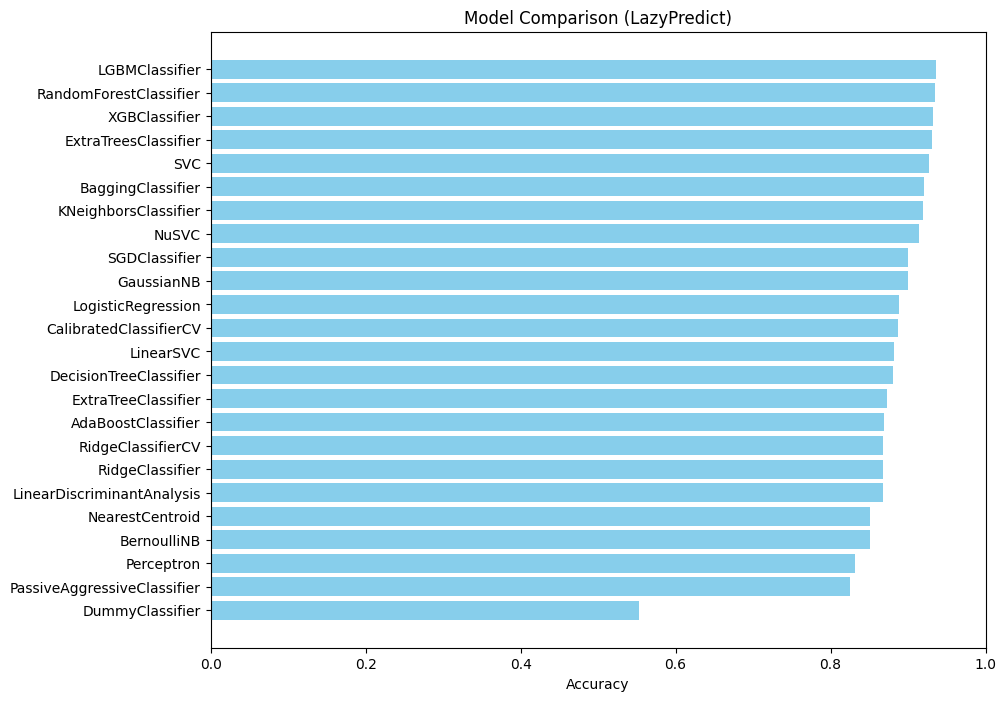

In [16]:
# Visualize models with there accuracy
plt.figure(figsize=(10,8))
plt.barh(models_sorted.index, models_sorted["Accuracy"], color="skyblue")
plt.xlabel("Accuracy")
plt.title("Model Comparison (LazyPredict)")
plt.xlim(0,1)
plt.show()

## Log Reg On Original Features

In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

param_grid = {
    'C': [0.001, 0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 300],
    'random_state': [42]
}

log_reg = LogisticRegression()

grid_search = GridSearchCV(
    log_reg, param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    verbose=3,
    n_jobs= -1
)

grid_search.fit(X_train, y_train)

# Best params
print(f"Best Params: {grid_search.best_params_}")
print(f"Best F1 Score (CV): {grid_search.best_score_:.4f}")

# Accuracy and F1 on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1 Score : {f1_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\Users\HP\OneDrive\Desktop\study\DS_Microsoft_S_Club_Content_tasks\phase2\Final-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\OneDrive\Desktop\study\DS_Microsoft_S_Club_Content_tasks\phase2\Final-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Params: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear'}
Best F1 Score (CV): 0.8616
Test Accuracy : 0.8483
Test F1 Score : 0.8615


In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(C = 0.01, max_iter = 100, penalty= 'l1', random_state= 42, solver= 'liblinear')
log_reg.fit(X_train, y_train)

C:\Users\HP\training_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\HP\training_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

              precision    recall  f1-score   support

         0.0       0.82      0.85      0.83     22472
         1.0       0.87      0.85      0.86     28049

    accuracy                           0.85     50521
   macro avg       0.85      0.85      0.85     50521
weighted avg       0.85      0.85      0.85     50521



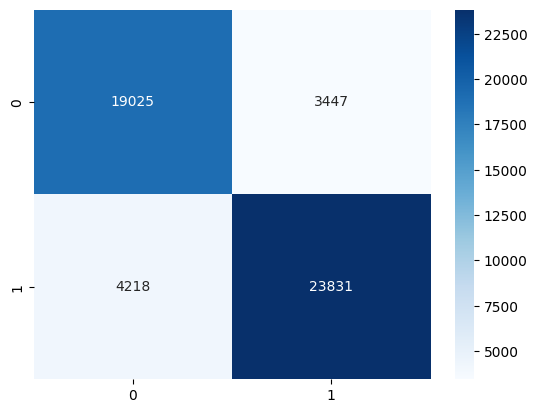

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_log = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_log))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot= True, cmap= 'Blues',fmt= 'd')
plt.show()

## Log Reg On new Features

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg_new = LogisticRegression(C = 0.01, max_iter = 100, penalty= 'l1', random_state= 42, solver= 'liblinear')
log_reg_new.fit(X_train_new, y_train_new)

C:\Users\HP\training_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\HP\training_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87     22472
         1.0       0.90      0.88      0.89     28049

    accuracy                           0.88     50521
   macro avg       0.88      0.88      0.88     50521
weighted avg       0.88      0.88      0.88     50521



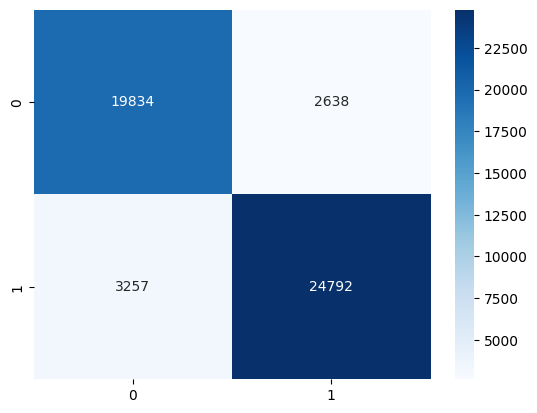

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_log_new = log_reg_new.predict(X_test_new)

print(classification_report(y_test_new, y_pred_log_new))

sns.heatmap(confusion_matrix(y_test, y_pred_log_new), annot= True, cmap= 'Blues',fmt= 'd')
plt.show()

              precision    recall  f1-score   support

         0.0       0.95      0.83      0.89     22472
         1.0       0.88      0.96      0.92     28049

    accuracy                           0.91     50521
   macro avg       0.91      0.90      0.90     50521
weighted avg       0.91      0.91      0.90     50521



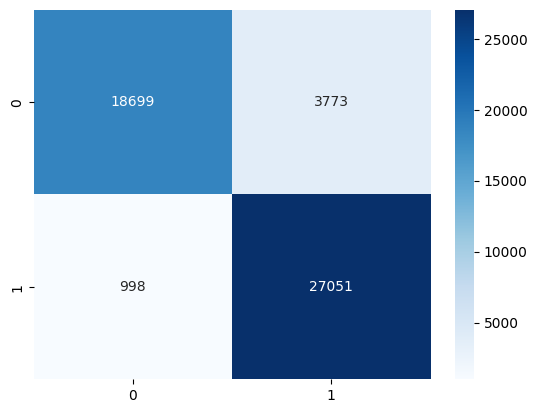

In [32]:
# edit the threshold

y_proba = log_reg_new.predict_proba(X_test_new)[:, 1]
y_pred_customed = (y_proba > 0.3)

print(classification_report(y_test_new, y_pred_customed))

sns.heatmap(confusion_matrix(y_test, y_pred_customed), annot= True, cmap= 'Blues',fmt= 'd')
plt.show()

## Random Forest

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

rf = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy'],
}

random_search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=30,              # بيجرب 30 combination بس
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    verbose=1,
    n_jobs=2,               # مش -1 عشان متاخدش RAM كتير
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best Params  : {random_search.best_params_}")
print(f"Best F1 (CV) : {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1 Score : {f1_score(y_test, y_pred):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\HP\training_env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params  : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'criterion': 'gini', 'class_weight': None}
Best F1 (CV) : 0.9459
Test Accuracy : 0.9374
Test F1 Score : 0.9466


In [11]:
from sklearn.ensemble import RandomForestClassifier

rnd = RandomForestClassifier(
    n_estimators= 300,
    max_depth= 20,
    min_samples_leaf= 1,
    min_samples_split= 10,
    max_features= 0.4,
    criterion= 'gini',
    random_state= 42,
    n_jobs= -1)

rnd.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

Classification Report : 
               precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     22472
         1.0       0.90      1.00      0.95     28049

    accuracy                           0.94     50521
   macro avg       0.95      0.93      0.93     50521
weighted avg       0.94      0.94      0.94     50521

Acc : 
 0.936758971516795


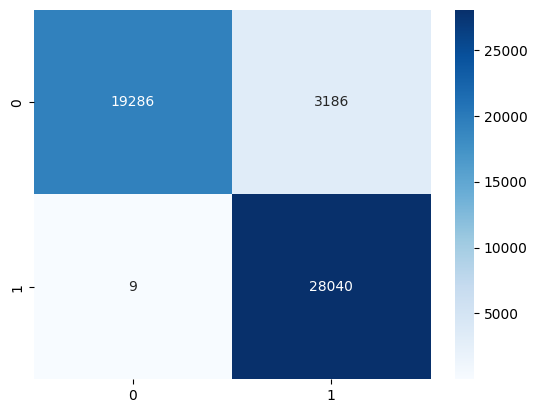

In [12]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

y_pred_rnd= rnd.predict(X_test)
print(f"Classification Report : \n {classification_report(y_test, y_pred_rnd)}")
print(f"Acc : \n {accuracy_score(y_test, y_pred_rnd)}")

sns.heatmap(confusion_matrix(y_test, y_pred_rnd), cmap= 'Blues', annot = True, fmt= 'd')
plt.show()

In [13]:
import pandas as pd

feature_importance = pd.Series(
    rnd.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Support Calls                 0.299994
Total Spend                   0.209632
Payment Delay                 0.141171
Age                           0.121301
Contract Length_Monthly       0.102936
Last Interaction              0.051467
Tenure                        0.024584
Usage Frequency               0.014994
Gender_Male                   0.010320
Gender_Female                 0.008066
Contract Length_Annual        0.005914
Contract Length_Quarterly     0.004087
Subscription Type_Basic       0.002249
Subscription Type_Standard    0.001650
Subscription Type_Premium     0.001634
dtype: float64


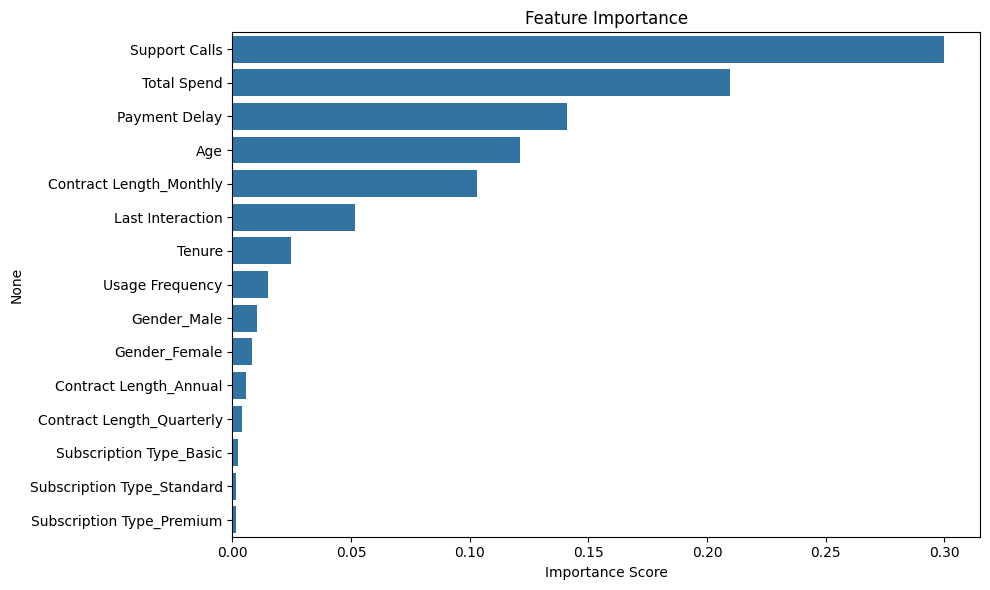

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## XGB

In [18]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive

xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    xgb, param_grid,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3),
    scoring='f1',
    verbose=1,
    n_jobs=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best Params  : {random_search.best_params_}")
print(f"Best F1 (CV) : {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1 Score : {f1_score(y_test, y_pred):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\HP\training_env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params  : {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best F1 (CV) : 0.9438
Test Accuracy : 0.9348
Test F1 Score : 0.9443


In [18]:
from xgboost import XGBClassifier

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive
print(f"scale_pos_weight = {scale:.2f}")

xgb = XGBClassifier(
    n_estimators=350,
    max_depth=10,
    learning_rate=0.1,
    subsample=1,
    colsample_bytree=1,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

scale_pos_weight = 0.80


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     22472
         1.0       0.90      1.00      0.95     28049

    accuracy                           0.94     50521
   macro avg       0.95      0.93      0.93     50521
weighted avg       0.94      0.94      0.93     50521



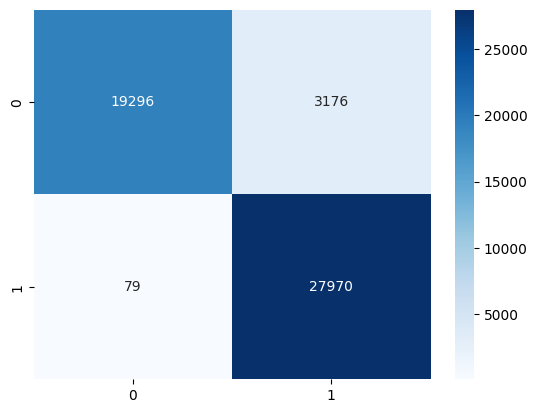

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap= 'Blues', fmt= 'd', annot= True)
plt.show()

## LGBM

In [21]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive

lgbm = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 50],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
}

random_search = RandomizedSearchCV(
    lgbm, param_grid,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    verbose=1,
    n_jobs=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best Params  : {random_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\HP\training_env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 252443, number of negative: 202242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 487
[LightGBM] [Info] Number of data points in the train set: 454685, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555204 -> initscore=0.221720
[LightGBM] [Info] Start training from score 0.221720
Best Params  : {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [51]:
from lightgbm import LGBMClassifier

# Scale
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive
lgbm = LGBMClassifier(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0.5,
    num_leaves=31,
    n_estimators=300,
    min_child_samples=20,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 252443, number of negative: 202242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 487
[LightGBM] [Info] Number of data points in the train set: 454685, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555204 -> initscore=0.221720
[LightGBM] [Info] Start training from score 0.221720


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Test Accuracy :               precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     22472
         1.0       0.90      1.00      0.95     28049

    accuracy                           0.94     50521
   macro avg       0.95      0.93      0.93     50521
weighted avg       0.94      0.94      0.94     50521



<Axes: >

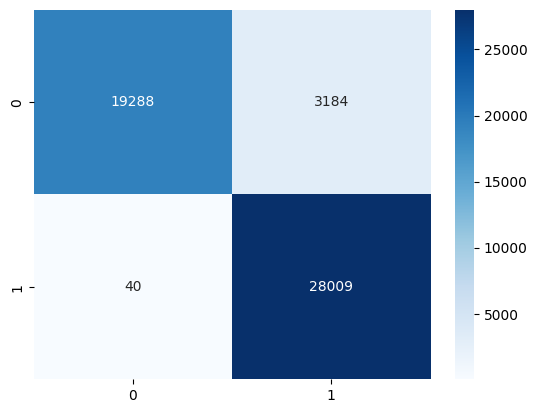

In [52]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_lgbm = lgbm.predict(X_test)

print(f"Test Accuracy : {classification_report(y_test, y_pred_lgbm)}")

sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), cmap= 'Blues', annot= True, fmt= 'd')

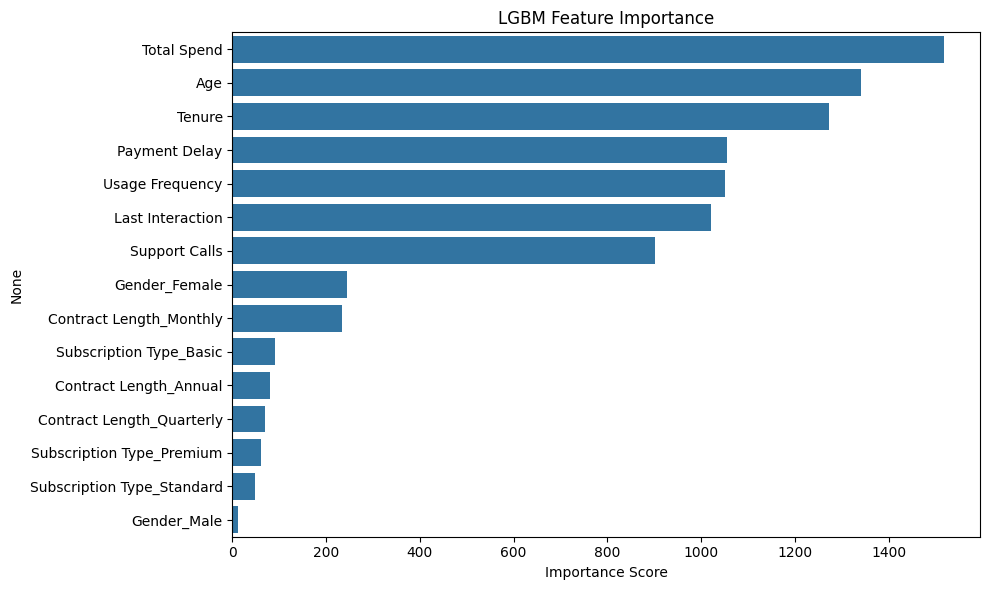

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('LGBM Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## LGBM With Selected Features (best model)

In [21]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=lgbm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
rfecv.fit(X_train, y_train)

selected_features = X_train.columns[rfecv.support_].tolist()
print(f"Optimal features: {rfecv.n_features_}")
print(selected_features)

[LightGBM] [Info] Number of positive: 252443, number of negative: 202242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 487
[LightGBM] [Info] Number of data points in the train set: 454685, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555204 -> initscore=0.221720
[LightGBM] [Info] Start training from score 0.221720
[LightGBM] [Info] Number of positive: 252443, number of negative: 202242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 485
[LightGBM] [Info] Number of data points in the train set: 454685, number of used features: 14
[LightGBM] [Info

In [54]:
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

lgbm_final = LGBMClassifier(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0.5,
    num_leaves=31,
    n_estimators=300,
    min_child_samples=20,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)

lgbm_final.fit(X_train_selected, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 252443, number of negative: 202242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 477
[LightGBM] [Info] Number of data points in the train set: 454685, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555204 -> initscore=0.221720
[LightGBM] [Info] Start training from score 0.221720


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Test Accuracy : 
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     22472
         1.0       0.94      1.00      0.97     28049

    accuracy                           0.97     50521
   macro avg       0.97      0.96      0.97     50521
weighted avg       0.97      0.97      0.97     50521



<Axes: >

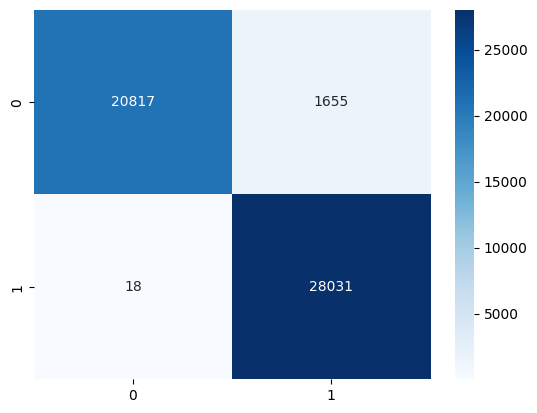

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_lgbm = lgbm_final.predict(X_test_selected)

print(f"Test Accuracy : \n{classification_report(y_test, y_pred_lgbm)}")

sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), cmap= 'Blues', annot= True, fmt= 'd')

# Saving the models

In [16]:
import joblib

# rnd
joblib.dump(rnd, '../models/RandomForest.pkl')


['../models/RandomForest.pkl']

In [60]:
import joblib

#lgbm
joblib.dump(lgbm_final, "../models/LGBMClassifier.pkl")

['../models/LGBMClassifier.pkl']

In [10]:
import joblib

# Save
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(encoder, '../models/encoder.pkl')


['../models/encoder.pkl']